# NetFlow Predictor — Progress Summary

**Research question:** Do MAAD features (Spectrum / Structure) add predictive value for next-window unique IP behavior?

**Key findings so far:**
1. Predicting the *change* (delta) in unique IP count is more informative than predicting the raw count
2. Structure features consistently outperform Spectrum features
3. All three Structure sub-blocks contribute — no single component explains the gain alone
4. XGBoost with compact `structure_region_summary` is the current best model (test R² +0.209 vs persistence)
5. The right tail of the Structure τ curve (`tau_sample_4`) is the strongest single feature

---
**Metric guide:**  
Values shown are *delta vs the persistence baseline* (predict current count / predict zero change).  
- MAE delta: **negative = better** (model beats baseline)  
- R² delta: **positive = better** (model explains more variance than baseline)

In [2]:
import html
import pandas as pd
from IPython.display import SVG, display, Markdown

def make_bar_svg(df, label_col, value_col, title, positive_good=False, width=900, row_height=28):
    if df.empty:
        return SVG('<svg xmlns="http://www.w3.org/2000/svg" width="800" height="40"><text x="10" y="25">no data</text></svg>')
    values = df[value_col].tolist()
    labels = df[label_col].tolist()
    max_abs = max(abs(v) for v in values) or 1.0
    left_margin = 320
    right_margin = 140
    top_margin = 45
    center_x = left_margin + (width - left_margin - right_margin) / 2
    chart_half_width = (width - left_margin - right_margin) / 2
    height = top_margin + len(df) * row_height + 30
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">',
        '<style>text { font-family: Menlo, monospace; font-size: 12px; } .title { font-size: 16px; font-weight: bold; }</style>',
        f'<text class="title" x="12" y="24">{html.escape(title)}</text>',
        f'<line x1="{center_x:.1f}" y1="35" x2="{center_x:.1f}" y2="{height - 15}" stroke="#777" stroke-width="1" />'
    ]
    for idx, (label, value) in enumerate(zip(labels, values)):
        y = top_margin + idx * row_height
        bar_width = chart_half_width * abs(value) / max_abs
        x = center_x if value >= 0 else center_x - bar_width
        if positive_good:
            fill = '#2ca02c' if value >= 0 else '#d62728'
        else:
            fill = '#2ca02c' if value <= 0 else '#d62728'
        parts.append(f'<text x="12" y="{y + 14}">{html.escape(str(label))}</text>')
        parts.append(f'<rect x="{x:.1f}" y="{y}" width="{bar_width:.1f}" height="18" fill="{fill}" opacity="0.85" rx="2" />')
        parts.append(f'<text x="{center_x + chart_half_width + 12:.1f}" y="{y + 14}">{value:+.4f}</text>')
    parts.append('</svg>')
    return SVG(''.join(parts))

## 1. Exact Count vs Delta Prediction

The first key finding: predicting the *raw next count* is nearly impossible to beat — the signal is dominated by persistence (the current count is already a near-perfect predictor of the next count, R² ≈ 0.999). Adding any learned features only hurts.

Switching to **delta prediction** (predicting the change from window to window) removes the persistence floor and exposes the signal that MAAD features carry. Structure features beat the zero-change baseline meaningfully in this framing.

**Exact-count models — all above zero means all worse than persistence:**

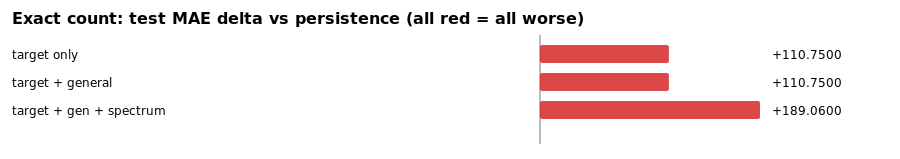

**Delta models — Structure pushes into the green:**

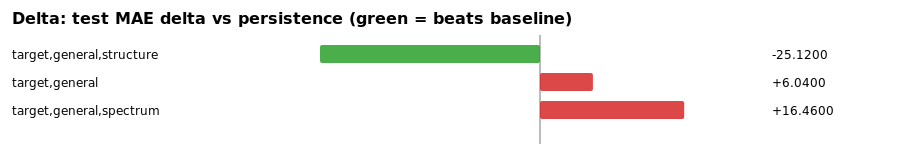

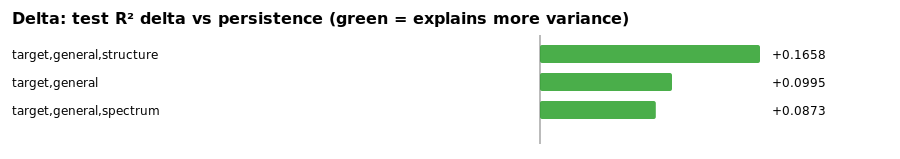

In [3]:
PERSIST_TEST_MAE = 549.71
PERSIST_TEST_R2  = 0.0  # delta baseline = predict zero

exact_rows = [
    {'task': 'exact count',  'blocks': 'target only',          'model_test_mae': 660.46, 'model_test_r2': 0.998698},
    {'task': 'exact count',  'blocks': 'target + general',     'model_test_mae': 660.46, 'model_test_r2': 0.998698},
    {'task': 'exact count',  'blocks': 'target + gen + spectrum','model_test_mae': 738.77, 'model_test_r2': 0.998590},
]
delta_rows = [
    {'task': 'delta', 'blocks': 'target,general',              'model_test_mae': 555.75, 'model_test_r2': 0.099487},
    {'task': 'delta', 'blocks': 'target,general,spectrum',     'model_test_mae': 566.17, 'model_test_r2': 0.087327},
    {'task': 'delta', 'blocks': 'target,general,structure',    'model_test_mae': 524.59, 'model_test_r2': 0.165848},
]

PERSIST_EXACT_MAE = 549.71  # same scale for comparison

exact_df = pd.DataFrame(exact_rows)
exact_df['test_mae_delta'] = exact_df['model_test_mae'] - PERSIST_EXACT_MAE

delta_df = pd.DataFrame(delta_rows)
delta_df['test_mae_delta'] = delta_df['model_test_mae'] - PERSIST_TEST_MAE
delta_df['test_r2_delta']  = delta_df['model_test_r2']  - PERSIST_TEST_R2

display(Markdown('**Exact-count models — all above zero means all worse than persistence:**'))
display(make_bar_svg(exact_df.sort_values('test_mae_delta'), 'blocks', 'test_mae_delta',
                     'Exact count: test MAE delta vs persistence (all red = all worse)', positive_good=False, width=900))

display(Markdown('**Delta models — Structure pushes into the green:**'))
display(make_bar_svg(delta_df.sort_values('test_mae_delta'), 'blocks', 'test_mae_delta',
                     'Delta: test MAE delta vs persistence  (green = beats baseline)', positive_good=False, width=900))
display(make_bar_svg(delta_df.sort_values('test_r2_delta', ascending=False), 'blocks', 'test_r2_delta',
                     'Delta: test R² delta vs persistence  (green = explains more variance)', positive_good=True, width=900))

## 2. Structure Ablation — Which Sub-blocks Contribute?

Structure features come in three sub-blocks:
- **`structure_summary`** — min/max/mean/std reductions over the τ and sd curves
- **`structure_tau_samples`** — fixed sampled points along the τ (main) curve
- **`structure_sd_samples`** — fixed sampled points along the sd (spread) curve

Each sub-block adds value; the best single combination is `summary + sd_samples`, and using all three together is best overall. **No single sub-block explains the full gain** — the signal is distributed across the curve.

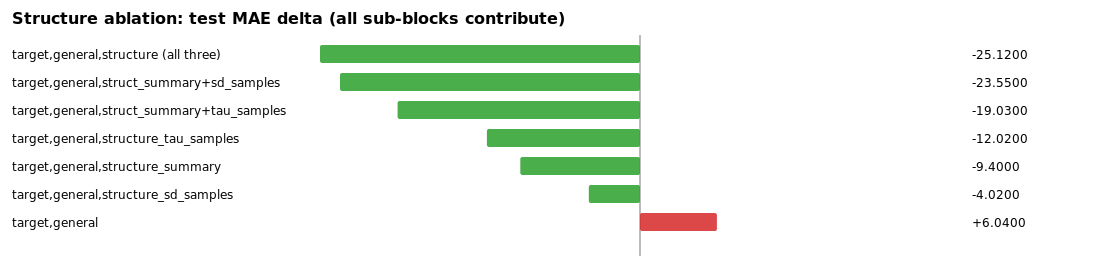

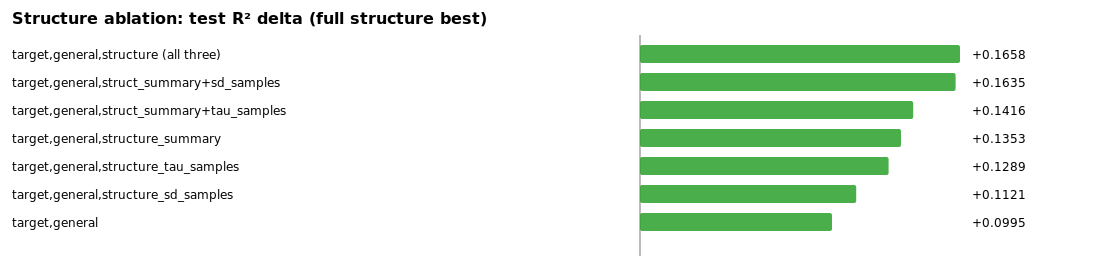

In [4]:
structure_rows = [
    {'blocks': 'target,general',                                      'model_test_mae': 555.75, 'model_test_r2': 0.099487},
    {'blocks': 'target,general,structure_summary',                    'model_test_mae': 540.31, 'model_test_r2': 0.135270},
    {'blocks': 'target,general,structure_tau_samples',                'model_test_mae': 537.69, 'model_test_r2': 0.128867},
    {'blocks': 'target,general,structure_sd_samples',                 'model_test_mae': 545.69, 'model_test_r2': 0.112071},
    {'blocks': 'target,general,struct_summary+tau_samples',           'model_test_mae': 530.68, 'model_test_r2': 0.141590},
    {'blocks': 'target,general,struct_summary+sd_samples',            'model_test_mae': 526.16, 'model_test_r2': 0.163544},
    {'blocks': 'target,general,structure (all three)',                'model_test_mae': 524.59, 'model_test_r2': 0.165848},
]

struct_df = pd.DataFrame(structure_rows)
struct_df['test_mae_delta'] = struct_df['model_test_mae'] - PERSIST_TEST_MAE
struct_df['test_r2_delta']  = struct_df['model_test_r2']  - PERSIST_TEST_R2

display(make_bar_svg(struct_df.sort_values('test_mae_delta'), 'blocks', 'test_mae_delta',
                     'Structure ablation: test MAE delta  (all sub-blocks contribute)', positive_good=False, width=1100))
display(make_bar_svg(struct_df.sort_values('test_r2_delta', ascending=False), 'blocks', 'test_r2_delta',
                     'Structure ablation: test R² delta  (full structure best)', positive_good=True, width=1100))

## 3. XGBoost — Trees Prefer Compact Structure Summaries

Running the same feature matrix through XGBoost (gradient-boosted trees) reveals a different preference: **`structure_region_summary`** — a compact encoding that collapses the curve into per-region stats — outperforms both the full Structure block and all Spectrum variants.

Key takeaways:
- Trees achieve **R² +0.209 vs persistence**, up from +0.166 with the best linear model
- Spectrum features remain below the structure alternatives under trees too
- The compact summary (`region_summary`) generalizes better for trees than the full sampled curve

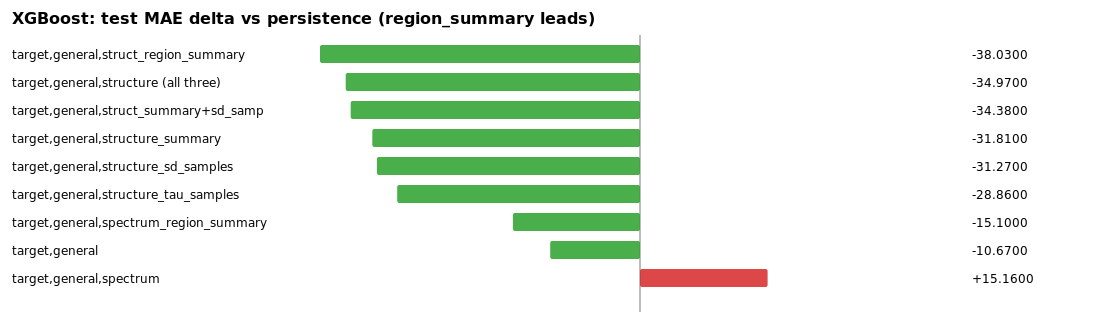

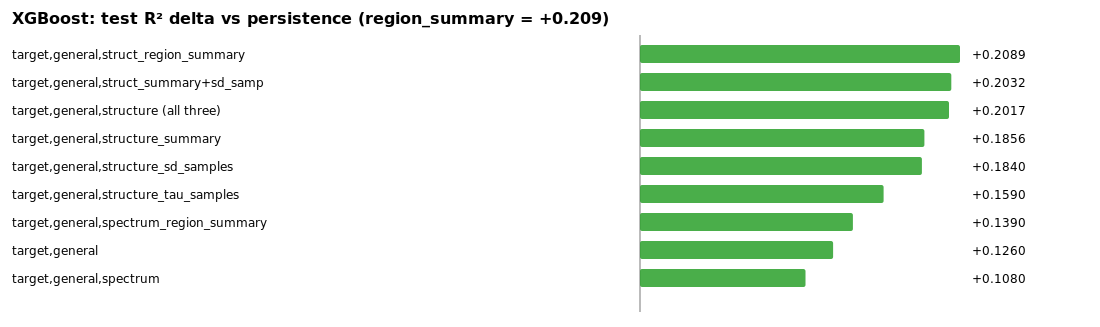

In [5]:
xgb_rows = [
    {'blocks': 'target,general',                        'model_test_mae': 539.04, 'model_test_r2': 0.126021},
    {'blocks': 'target,general,spectrum',               'model_test_mae': 564.87, 'model_test_r2': 0.108022},
    {'blocks': 'target,general,spectrum_region_summary','model_test_mae': 534.61, 'model_test_r2': 0.138998},
    {'blocks': 'target,general,structure_summary',      'model_test_mae': 517.90, 'model_test_r2': 0.185609},
    {'blocks': 'target,general,structure_tau_samples',  'model_test_mae': 520.85, 'model_test_r2': 0.159035},
    {'blocks': 'target,general,structure_sd_samples',   'model_test_mae': 518.44, 'model_test_r2': 0.184007},
    {'blocks': 'target,general,struct_summary+sd_samp', 'model_test_mae': 515.33, 'model_test_r2': 0.203184},
    {'blocks': 'target,general,structure (all three)',  'model_test_mae': 514.74, 'model_test_r2': 0.201700},
    {'blocks': 'target,general,struct_region_summary',  'model_test_mae': 511.68, 'model_test_r2': 0.208874},
]

xgb_df = pd.DataFrame(xgb_rows)
xgb_df['test_mae_delta'] = xgb_df['model_test_mae'] - PERSIST_TEST_MAE
xgb_df['test_r2_delta']  = xgb_df['model_test_r2']  - PERSIST_TEST_R2

display(make_bar_svg(xgb_df.sort_values('test_mae_delta'), 'blocks', 'test_mae_delta',
                     'XGBoost: test MAE delta vs persistence  (region_summary leads)', positive_good=False, width=1100))
display(make_bar_svg(xgb_df.sort_values('test_r2_delta', ascending=False), 'blocks', 'test_r2_delta',
                     'XGBoost: test R² delta vs persistence  (region_summary = +0.209)', positive_good=True, width=1100))

## 4. Feature Importance — What's Driving the Signal?

Standardized linear coefficients from the best linear model (`target,general,structure` at 200 epochs). Larger absolute value = stronger influence within this model.

Observations:
- **`structure_tau_sample_4`** (rightmost sampled point of the τ curve) is the single strongest feature (coeff 0.879)
- **`structure_sd_mean`** and **`structure_sd_sample_3`** are close behind — the *sd* dimension carries real signal
- Signal is spread across all three sub-blocks (tau samples, sd samples, summary stats) — confirms no single group is dispensable
- Summary statistics are primary signal, not just backup features

> Note: coefficient sign can be ambiguous in correlated features; use absolute magnitude for ranking.

In [ ]:
ranking_rows = [
    ('structure_tau_sample_4',  0.879342, 'tau_samples'),
    ('structure_sd_mean',       0.695006, 'summary'),
    ('structure_sd_sample_3',   0.647577, 'sd_samples'),
    ('structure_sd_std',       -0.533628, 'summary'),
    ('structure_sd_sample_4',  -0.433997, 'sd_samples'),
    ('structure_tau_max',      -0.410644, 'summary'),
    ('structure_tau_sample_3', -0.409847, 'tau_samples'),
    ('structure_tau_sample_1', -0.176833, 'tau_samples'),
    ('structure_tau_std',       0.175182, 'summary'),
    ('structure_tau_mean',      0.150282, 'summary'),
    ('structure_sd_sample_1',  -0.104520, 'sd_samples'),
    ('structure_points',        0.098643, 'summary'),
    ('structure_sd_sample_0',   0.088807, 'sd_samples'),
    ('structure_tau_sample_0',  0.080282, 'tau_samples'),
    ('structure_tau_min',      -0.048567, 'summary'),
]

rank_df = pd.DataFrame(ranking_rows, columns=['feature', 'coefficient', 'group'])
rank_df['abs_coeff'] = rank_df['coefficient'].abs()
rank_df = rank_df.sort_values('abs_coeff', ascending=False).reset_index(drop=True)

display(make_bar_svg(rank_df, 'feature', 'coefficient',
                     'Ranked Structure coefficients (linear model, standardized)',
                     positive_good=True, width=1000, row_height=24))

group_totals = rank_df.groupby('group')['abs_coeff'].sum().sort_values(ascending=False)
display(Markdown('**Group totals (sum of |coefficient|):**'))
display(group_totals.to_frame('total_abs_coeff').reset_index())

## Summary

| Finding | Result |
|---|---|
| Exact count prediction | Persistence-dominated; learned features hurt |
| Delta prediction | Exposes useful signal; Structure beats baseline |
| Best linear model | `target,general,structure` → test R² +0.166 |
| Best tree model | `target,general,structure_region_summary` → test R² +0.209 |
| Structure vs Spectrum | Structure consistently outperforms Spectrum |
| Feature driver | Right tail of τ curve + sd mean/spread; distributed across all sub-blocks |

**Next analysis:** XGBoost grouped permutation importance on `structure_region_summary` to understand which regions of the Structure curve matter most under trees.